<a href="https://colab.research.google.com/github/sutikshna1998-bot/sunnytiwari.github.io/blob/main/Session%2001/IS883_Session01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Language Modeling with N-grams on a Real Book Corpus

### What you will do in this notebook

In class we built a tiny n-gram on three toy sentences. Here we scale it up to a **real corpus**: a few hundred thousand words of public-domain children's literature (*Alice in Wonderland*, *Stories to Tell to Children*, *The Adventures of Buster Bear*, and *The Parent's Assistant*), all from Project Gutenberg.

You will:

1. Load and inspect a large text corpus.
2. Train n-gram language models on it.
3. See what changes when you change **n**.
4. See that the same model gives **different text every run** (stochasticity).
5. Use the model for **text completion** from different prefixes.
6. Measure model quality with **perplexity**.

# Part 0: Setup

In [1]:
# Install the one library this notebook needs.
!pip install nltk --quiet

Machine learning is generally stochastic, meaning you get different results for different runs. To control that, we "seed" the code. Enter your BUID below; it is passed as the seed wherever we want a result you can reproduce. (In Part 5 we deliberately leave the seed out, to show what happens without it.)

In [24]:
# Your BUID seeds every random step so your results are reproducible.
BUID = U81402186  # enter ONLY the numerical part

NameError: name 'U81402186' is not defined

In [3]:
# Bring in Python's random number generator; we hand it BUID as the seed at each random step.
import random

# Part 1: Getting a Large Text Corpus

`nltk` ships with a sample of Project Gutenberg books. We download it once and then pick the four books that are children's literature.

Notice how little code this takes: `gutenberg.sents(book)` hands us the book **already split into sentences and already split into words**. No manual text cleaning needed.

In [25]:
# Download NLTK's sample of Project Gutenberg books and list what's available.
import nltk

nltk.download('gutenberg')
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.corpus import gutenberg

print("Available books:", gutenberg.fileids())

Available books: ['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt', 'bible-kjv.txt', 'blake-poems.txt', 'bryant-stories.txt', 'burgess-busterbrown.txt', 'carroll-alice.txt', 'chesterton-ball.txt', 'chesterton-brown.txt', 'chesterton-thursday.txt', 'edgeworth-parents.txt', 'melville-moby_dick.txt', 'milton-paradise.txt', 'shakespeare-caesar.txt', 'shakespeare-hamlet.txt', 'shakespeare-macbeth.txt', 'whitman-leaves.txt']


[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [26]:
# Load four children's books and combine them into one list of sentences.
# gutenberg.sents() returns each sentence already split into words.
books = [
    'carroll-alice.txt',          # Alice's Adventures in Wonderland
    'bryant-stories.txt',         # Stories to Tell to Children
    'burgess-busterbrown.txt',    # The Adventures of Buster Bear
    'edgeworth-parents.txt',      # The Parent's Assistant
]

sentences = []
for book in books:
    # Lower-case every word so "The" and "the" count as the same word
    book_sentences = [[word.lower() for word in sentence] for sentence in gutenberg.sents(book)]
    sentences = sentences + book_sentences
    print(f"{book:30s} {len(book_sentences):6d} sentences, {len(gutenberg.words(book)):7d} words")

print()
print("TOTAL:", len(sentences), "sentences,", sum(len(s) for s in sentences), "words")

carroll-alice.txt                1703 sentences,   34110 words
bryant-stories.txt               2863 sentences,   55563 words
burgess-busterbrown.txt          1054 sentences,   18963 words
edgeworth-parents.txt           10230 sentences,  210663 words

TOTAL: 15850 sentences, 319326 words


Let's look at a few sentences to see what the model will actually be trained on.

In [28]:
# Peek at the first few sentences to see what the model will train on.
for sentence in sentences[:5]:
    print(' '.join(sentence))
    print('---')

[ alice ' s adventures in wonderland by lewis carroll 1865 ]
---
chapter i .
---
down the rabbit - hole
---
alice was beginning to get very tired of sitting by her sister on the bank , and of having nothing to do : once or twice she had peeped into the book her sister was reading , but it had no pictures or conversations in it , ' and what is the use of a book ,' thought alice ' without pictures or conversation ?'
---
so she was considering in her own mind ( as well as she could , for the hot day made her feel very sleepy and stupid ), whether the pleasure of making a daisy - chain would be worth the trouble of getting up and picking the daisies , when suddenly a white rabbit with pink eyes ran close by her .
---


### Train / test split

We hold out part of the data. The model **only** sees the training sentences. The test sentences are used later to measure how well the model generalizes.

In [7]:
# Shuffle, then hold out 10% of the sentences as a test set the model never sees.
random.Random(BUID).shuffle(sentences)   # shuffle so the split mixes all four books

training_split = 0.9
split_point = int(training_split * len(sentences))
train_sentences = sentences[:split_point]
test_sentences = sentences[split_point:]

print("training sentences:", len(train_sentences))
print("test sentences    :", len(test_sentences))

training sentences: 14265
test sentences    : 1585


# Part 2: Training an N-gram Language Model

`nltk` does the heavy lifting. `padded_everygram_pipeline` adds the `<s>` (start) and `</s>` (end) markers and counts every n-gram. We wrap it in a small function so we can train a model for any `n` with one line.

**Smoothing.** We train with `Lidstone`, which adds a tiny amount (0.01) to every word count. Without it, a word combination the model never saw in training would have probability exactly zero — and a single zero drags the whole sentence's probability to zero, which breaks the perplexity arithmetic in Part 7. Smoothing keeps unseen combinations merely *unlikely* rather than *impossible*.

**Three different "sizes".** The cell below prints three counts, plus one ratio, and they behave very differently as `n` changes. The **vocabulary** is how many distinct words appear in the books — it belongs to the *corpus*, so it barely moves. The **stored n-grams** are what the model memorized, and the **contexts** are the distinct runs of `n - 1` words it saw right before a word — both belong to the *model*, and they grow quickly as `n` grows. The last line divides one by the other: **continuations per context** is how many different next words the model saw, on average, after each context.

In [31]:
# Train an n-gram model for a given n, then report three different "sizes" of the result.
from nltk.lm import Lidstone
from nltk.lm.preprocessing import padded_everygram_pipeline

def train_ngram_model(n, sentences):
    train_data, vocabulary = padded_everygram_pipeline(n, sentences)   # add <s>/</s> and count n-grams
    model = Lidstone(0.01, n)                                          # 0.01 = the amount added to every count
    model.fit(train_data, vocabulary)
    return model

my_ngram_model = train_ngram_model(8, train_sentences)


def count_ngrams(model):
    """How many distinct n-grams the model stored, over how many contexts."""
    if model.order == 1:
        return len(model.counts.unigrams), 1     # a unigram model has no context, so count it as one
    contexts = model.counts[model.order]
    return sum(len(next_words) for next_words in contexts.values()), len(contexts)


num_ngrams, num_contexts = count_ngrams(my_ngram_model)

print("n =", my_ngram_model.order)
print("vocabulary size          :", f"{len(my_ngram_model.vocab):,}", "distinct words")
print("distinct n-grams stored  :", f"{num_ngrams:,}")
print("distinct contexts seen   :", f"{num_contexts:,}")
print("continuations per context:", f"{num_ngrams / num_contexts:.2f}")

n = 8
vocabulary size          : 10,135 distinct words
distinct n-grams stored  : 325,232
distinct contexts seen   : 311,343
continuations per context: 1.04


**Experiment.** Re-run the cell above with `n = 2`, then with `n = 5` (change the `4` in `train_ngram_model(4, train_sentences)`). Watch how the numbers move as `n` grows.

**Question 1.** The cell above prints three different "sizes" and one ratio. Which number barely changes as `n` grows, and which one changes sharply? What does a "continuations per context" close to 1 tell you the model will do when you ask it to generate text?

**Answer**

*Provide your answer here*

### What did the model actually learn?

An n-gram model is essentially a big lookup table: *given the previous word(s), how often did each word come next?* Let's look up a few phrases.

In [9]:
# Helper: show the words most likely to follow a given phrase, with their probabilities.
def show_next_words(model, previous_words, how_many=8):
    if isinstance(previous_words, str):
        previous_words = previous_words.split()

    if len(previous_words) > model.order - 1:    # an n-gram model can only look back n-1 words
        print(f'This model (n = {model.order}) can only look back {model.order - 1} word(s), '
              f'but you gave it {len(previous_words)}. Train a model with n = {len(previous_words) + 1}.\n')
        return

    counts = model.counts[previous_words] if len(previous_words) > 0 else model.counts.unigrams
    total = sum(counts.values())
    phrase = " ".join(previous_words)

    if total == 0:
        print(f'"{phrase}" never appears in the training text.\n')
        return

    print(f'After "{phrase}" ({total} times in the training text), the most likely next words are:')
    for word, count in counts.most_common(how_many):
        print(f"   {word:12s} probability = {count / total:.3f}")
    print()

show_next_words(my_ngram_model, ["little"])
show_next_words(my_ngram_model, ["once", "upon"])
show_next_words(my_ngram_model, ["said"])

After "little" (1233 times in the training text), the most likely next words are:
   joe          probability = 0.079
   jackal       probability = 0.045
   boy          probability = 0.033
   girl         probability = 0.032
   red          probability = 0.028
   fir          probability = 0.019
   half         probability = 0.019
   gingerbread  probability = 0.019

After "once upon" (10 times in the training text), the most likely next words are:
   a            probability = 1.000

After "said" (2155 times in the training text), the most likely next words are:
   the          probability = 0.243
   ,            probability = 0.076
   he           probability = 0.067
   alice        probability = 0.046
   she          probability = 0.046
   to           probability = 0.038
   mr           probability = 0.025
   his          probability = 0.020



**Experiment.** Look up other words of your own by changing the words passed to `show_next_words` above. Can you find a word whose most-likely next words surprise you?

# Part 3: Generating Text

To generate text we repeatedly ask the model: *given the last n-1 words, what word comes next?* We stop when the model produces the end-of-sentence marker `</s>`.

The `seed` argument makes a run reproducible. If you leave it out, you get a different sample every time (we use that on purpose in Part 5).

In [10]:
# Generate text one word at a time, stopping at the sentence-end marker.
# Pass a prefix to continue from given words; pass a seed to make a run repeatable.
def generate_text(model, num_words=40, prefix=None, seed=None):
    n = model.order
    random_generator = random.Random(seed) if seed is not None else None

    context = ["<s>"] * (n - 1)          # pretend we are at the start of a sentence
    generated = []

    if prefix is not None:               # start from words the user gave us
        prefix_words = nltk.word_tokenize(prefix.lower())
        context = context + prefix_words
        generated = list(prefix_words)

    for _ in range(num_words):
        last_words = context[-(n - 1):] if n > 1 else []
        next_word = model.generate(text_seed=last_words, random_seed=random_generator)
        if next_word == "</s>":          # the model decided the sentence is over
            break
        if next_word == "<s>":           # skip start markers
            continue
        generated.append(next_word)
        context.append(next_word)

    return " ".join(generated)


print(generate_text(my_ngram_model, num_words=40, prefix="once", seed=None))

once a little mouse who lived in the little seed from the beginning , and are called canterbury bells .


**Experiment.** Set `seed=BUID` and re-run a few times — the text stays the same. Then change the `prefix` to a phrase of your own and see what the model writes.

# Part 4: Trying Different Values of n

`n` controls **how much context** the model is allowed to look at.

Below we train one model per value of `n` and generate a sentence from each, using the same seed so the comparison is fair.

**Warning:** this cell trains five models from scratch, so give it up to a minute.

In [11]:
# Train one model per value of n and print sample sentences from each.
# The same seed is used across models so the comparison is fair.
models = {}   # save the models so we can reuse them later

for n in [1, 2, 3, 4, 5]:
    models[n] = train_ngram_model(n, train_sentences)
    print(f"===== n = {n} =====")
    for sample in range(3):
        print(" ", generate_text(models[n], num_words=40, seed=BUID + 101 * n + sample))
    print()

===== n = 1 =====
  . difference yourselves . suddenly ." to to hardy ( , of making . which measuring of christmas until . anne he twelve alone other . ineffable you and could make one into evening the be " rory 1828 why
  . to bright or o believe can very , . with said the that the , plums to ) lazy burnt of t , the am dress ." you ! please while to that ( officers ! , do ."
  at sunshine the , of am secret something at hanging a t ; way ?" the afraid i lucky neither there knife i , , showed in do things papa reckon a stay certain this manner . the about _h_arbour

===== n = 2 =====
  it must not know in a good sense and green forest , if you to make over , my fireworks and sickness , would not know what do i were cut , and would feel encouraged to live in the
  presently the custom by one took care to him , i ' s no one ; it was looking up a few minutes , divided between yourself , lad who would , " what we ' t caught all had
  " party -- it to be as rubbish , and they live !"

=====

**Question 2.** Describe how the generated text changes as `n` grows. Which value of `n` gives the best-sounding sentences? What starts to go wrong at the high end?

**Answer**

*Provide your answer here*

# Part 5: Stochasticity — Same Model, Different Runs

An n-gram model does not output *the* next word; it outputs a **probability distribution** over next words, and we sample from it. So the same model, asked the same question, answers differently each time.

Here we run the same trigram model five times **without** fixing a seed.

In [12]:
# Run the SAME model five times with NO seed -> different text each run.
trigram_model = models[3]

for run in range(5):
    print(f"Run {run + 1}: {generate_text(trigram_model, num_words=30)}")
    print("---")

Run 1: 5th boy .
---
Run 2: they drew off on one knee .
---
Run 3: i am compelled , under which many generations of hopeful children had .
---
Run 4: and the light flash from his father ; " you do , come ," said the king smiling at seeing him ,-- the happy land of france , they ran
---
Run 5: they looked about him .
---


**Experiment.** Change which model the cell above uses (try `models[2]` or `models[5]`) and re-run. Do the five runs differ from each other more, or less?

**Question 3.** Why do we get different text on every run? And why is being able to fix the seed useful?

**Answer**

*Provide your answer here*

# Part 6: Text Completion with Different Prefixes

So far we started from an empty sentence. But we can also hand the model a **prefix** and ask it to continue — which is exactly what auto-complete on your phone does, and a simplified version of what ChatGPT does.

In [13]:
# Give the model a starting phrase (prefix) and let it finish the sentence.
demo_model = models[5]

prefixes = [
    "once upon a time",
    "the little girl",
    "alice was",
    "he said to",
    "the big data analyst",   # a prefix that does NOT belong to children's books
]

for i, prefix in enumerate(prefixes):
    print(f'PREFIX: "{prefix}"')
    print("  ->", generate_text(demo_model, num_words=30, prefix=prefix, seed=BUID + i))
    print("---")

PREFIX: "once upon a time"
  -> once upon a time there was a dear little girl , whose lap was full of primroses .
---
PREFIX: "the little girl"
  -> the little girl came back out of breath to her work ; but what was her surprise and sorrow to find it spoiled .
---
PREFIX: "alice was"
  -> alice was just beginning to understand something that peter rabbit and the other little people of the green forest and some from the green meadows saw him .
---
PREFIX: "he said to"
  -> he said to the field mouse .
---
PREFIX: "the big data analyst"
  -> the big data analyst suddenly , thump !
---


The same prefix through models of different `n`:

In [14]:
# Complete the same prefix with each n, and show the next-word options at each step.
prefix = "once upon a time"

for n in [1, 2, 3, 4, 5]:
    prefix_words = prefix.split(" ")
    last_words = prefix_words[-(n - 1):] if n > 1 else []   # the n-1 words the model looks back at
    print(f"n = {n}:")
    print("  ", generate_text(models[n], num_words=30, prefix=prefix, seed=BUID))
    show_next_words(models[n], last_words)
    print("---")

n = 1:
   once upon a time the that ' ; ! ones , away ," and how a ' upon faster of every there soul he he their i is that ). take , i ,
After "" (287425 times in the training text), the most likely next words are:
   ,            probability = 0.067
   the          probability = 0.042
   .            probability = 0.032
   and          probability = 0.027
   to           probability = 0.024
   '            probability = 0.019
   of           probability = 0.017
   a            probability = 0.016

---
n = 2:
   once upon a time they used , and , or adopted child , and make an ' then both proud king saul grew more frightened the little joe otter ' t be lonely .
After "time" (477 times in the training text), the most likely next words are:
   ,            probability = 0.184
   to           probability = 0.113
   .            probability = 0.088
   he           probability = 0.044
   the          probability = 0.031
   ;            probability = 0.027
   she          probability = 0.025

And the same prefix, same model, several times — stochasticity again, now in a completion setting:

In [15]:
# Same prefix, same model, five times -> stochasticity again, now while completing text.
prefix = "the little girl"

for run in range(5):
    print(generate_text(demo_model, num_words=25, prefix=prefix, seed=BUID + run))
    print("---")

the little girl gave the lace without reply , and the maid charged the child , " to look as if nothing was the matter ."
---
the little girl came back out of breath to her work ; but what was her surprise and sorrow to find it spoiled .
---
the little girl came back out of breath to speak , seized hold of him , and , when he was going away , stopped to ask him
---
the little girl gave the lace without reply , and the maid desired her to go about her business , and not to her , so she took
---
the little girl gave the lace without reply , and the maid desired her to go about her business , and not to her , so she took
---


**Question 4.** What happened with the prefix `"the big data analyst"`? Why?

**Answer**

*Provide your answer here*

# Part 7: Measuring Quality with Perplexity

Generated text is fun but subjective. **Perplexity** is the standard numeric score for a language model.

Intuition: perplexity is roughly *"on average, how many words was the model surprised with at each step?"* A perplexity of 10 means the model was about as uncertain as if it had been choosing uniformly among 10 words. **Lower is better.**

We compute it on text the model has never seen, since scoring the model on its own training text would be like grading a student on the exact questions they memorized.

In [16]:
# Reuse the bigram (the n = 2 model) trained in Part 4 to demonstrate perplexity.
bigram_model = models[2]

In [17]:
# Compute the perplexity of a single sentence (lower = the model is less surprised).
from nltk.util import ngrams
from nltk.lm.preprocessing import pad_both_ends

def sentence_perplexity(model, sentence):
    n = model.order
    tokens = nltk.word_tokenize(sentence.lower())
    tokens = list(pad_both_ends(tokens, n))       # add <s> ... </s>
    tokens = model.vocab.lookup(tokens)           # replace unknown words with <UNK>
    return model.perplexity(list(ngrams(tokens, n)))


test_sentence = "once upon a time there was a little boy."
print("perplexity =", sentence_perplexity(bigram_model, test_sentence))

perplexity = 24.798436885431716


### Comparing sentences

Now that perplexity is finite, we can use it to ask: *how surprised is a children's-book model by this sentence?*

In [18]:
# Score several sentences: children's-book style should be far less perplexing than business jargon.
sentences_to_score = [
    "once upon a time there was a little boy.",
    "the little girl said to her mother.",
    "alice was beginning to get very tired.",
    "the quarterly earnings report exceeded analyst expectations.",
    "blockchain optimizes shareholder value through synergistic frameworks.",
]

for sentence in sentences_to_score:
    score = sentence_perplexity(bigram_model, sentence)
    print(f"{score:10.1f}   {sentence}")

      24.8   once upon a time there was a little boy.
      39.5   the little girl said to her mother.
      54.8   alice was beginning to get very tired.
    1718.3   the quarterly earnings report exceeded analyst expectations.
    7176.0   blockchain optimizes shareholder value through synergistic frameworks.


### Perplexity vs. n

We measure perplexity on the **training** sentences and on the **held-out test** sentences, for each value of `n`, reusing the five models trained in Part 4.

**Warning:** this cell scores every model on both sets, so give it up to a minute.

In [19]:
# Measure perplexity on the training and the held-out test sentences, for each n.
def corpus_perplexity(model, sentences):
    all_ngrams = []
    for sentence in sentences:
        tokens = model.vocab.lookup(list(pad_both_ends(sentence, model.order)))
        all_ngrams.extend(ngrams(tokens, model.order))
    return model.perplexity(all_ngrams)


range_of_n = [1, 2, 3, 4, 5]
train_perplexities = []
test_perplexities = []

for n in range_of_n:
    model = models[n]                     # reuse the models trained in Part 4
    train_perplexities.append(corpus_perplexity(model, train_sentences))
    test_perplexities.append(corpus_perplexity(model, test_sentences))
    print(f"n = {n}:  train perplexity = {train_perplexities[-1]:8.1f}   test perplexity = {test_perplexities[-1]:8.1f}")

n = 1:  train perplexity =    469.4   test perplexity =    520.8
n = 2:  train perplexity =     67.7   test perplexity =    194.7
n = 3:  train perplexity =     55.0   test perplexity =    636.5
n = 4:  train perplexity =     63.5   test perplexity =   1645.9
n = 5:  train perplexity =     68.9   test perplexity =   2409.9


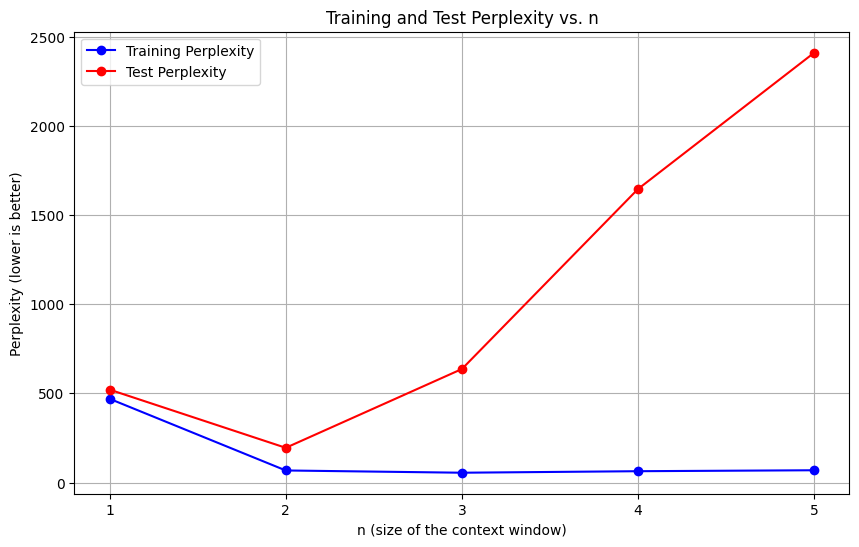

In [20]:
# Plot training vs. test perplexity against n. The gap between the lines is overfitting.
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range_of_n, train_perplexities, label='Training Perplexity', color='blue', marker='o')
plt.plot(range_of_n, test_perplexities, label='Test Perplexity', color='red', marker='o')
plt.xlabel('n (size of the context window)')
plt.ylabel('Perplexity (lower is better)')
plt.title('Training and Test Perplexity vs. n')
plt.xticks(range_of_n)
plt.legend()
plt.grid(True)
plt.show()

**Question 5.** Read the plot. Which values of `n` underfit, which overfit, and which is best? What is the gap between the two lines telling you?

**Answer**

*Provide your answer here*

# Part 8: Follow up Questions and Exercises

**Exercise 1.** Retrain the models on a *different* genre from the same collection — for example `['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt']` (Jane Austen) or `['shakespeare-hamlet.txt', 'shakespeare-macbeth.txt', 'shakespeare-caesar.txt']`. Generate text from the new trigram. Can you tell the genre from the generated text alone?

In [21]:
# Your code here

**Answer**

*Provide your answer here*

**Exercise 2.** Score the sentence `"once upon a time there was a little boy."` with **both** the children's-book model and your new model from Exercise 1. Which model is less perplexed, and why? What does this tell you about what perplexity actually measures?

In [22]:
# Your code here

**Answer**

*Provide your answer here*

**Exercise 3.** Rerun the notebook with less training data and more test data. How do the results change?

In [23]:
# Your code here

**Answer**

*Provide your answer here*